# Comparing DDM and racing diffusion model on Garcia 2022

Both models share the **same Bayesian-observer cognitive front-end** (asymmetric encoding noise, log-normal prior, posterior-mean estimates) but differ in the response-time mechanism:

- **DDM**: a single accumulator tracks the difference $\mu_{\text{post},2} - \mu_{\text{post},1}$. Drift is the SNR of the perceived difference, scaled by $1/\sqrt{\nu_1^2 + \nu_2^2}$. Predicts the size effect inversely (with Weber noise, larger magnitudes → slower).
- **Racing diffusion model (RDM)**: each stimulus has its own Wiener accumulator. Drift on accumulator $k$ is $\mu_{\text{post},k}$ (Bayesian-pulled mean). Per-accumulator diffusion noise is $\sigma_k = \beta_k\nu_k$ — the SD of the posterior mean given a fixed objective $n_k$. Predicts faster RTs for larger numbers (drift $\uparrow$ with $\log n$).

Both fit jointly to choice + RT via analytical likelihoods. We compare via:

1. **PPC** (psychometric, chronometric, size-effect plots) — qualitative fit.
2. **PSIS-LOO** via per-trial log-likelihood — quantitative ELPD comparison.

Cached fits live in `notebooks/results/garcia_{ddm,race}_idata.nc` (small fit, ~6 subjects). Run `python notebooks/fit_ddm_garcia.py [--full]` to refit.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import os.path as op

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from bauer.utils.data import load_garcia2022
from bauer.utils.bayes import summarize_ppc_group
from bauer.models import (
    DDMMagnitudeComparisonModel,
    RaceDiffusionMagnitudeComparisonModel,
)

sns.set_theme(style='ticks', context='notebook')

In [2]:
NB_DIR = op.dirname(op.abspath(globals().get('__file__', op.join(os.getcwd(), 'placeholder'))))
if not op.isdir(NB_DIR):
    NB_DIR = '.'

for cdir_name in ['results_full', 'results']:
    cdir = op.join(NB_DIR, cdir_name)
    if op.exists(op.join(cdir, 'garcia_race_idata.nc')):
        RESULTS_DIR = cdir
        break
else:
    raise FileNotFoundError('No race fit found. Run fit_ddm_garcia.py first.')

idata_ddm  = az.from_netcdf(op.join(RESULTS_DIR, 'garcia_ddm_idata.nc'))
idata_race = az.from_netcdf(op.join(RESULTS_DIR, 'garcia_race_idata.nc'))
print(f'loaded fits from {RESULTS_DIR}')

df = load_garcia2022(task='magnitude')
fit_subjects = idata_ddm.posterior.coords['subject'].values
df = df.loc[df.index.get_level_values('subject').isin(fit_subjects)].copy()
print(f'using {len(df)} trials, {len(fit_subjects)} subjects')

loaded fits from /Users/gdehol/git/bauer/notebooks/results
using 1234 trials, 6 subjects


In [3]:
print('--- DDM ---')
print(az.summary(idata_ddm, var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu',
                                         'a_mu', 'z_mu', 't0_mu'], round_to=3))
print('\n--- racing diffusion ---')
print(az.summary(idata_race, var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu',
                                         'a_mu', 't0_mu'], round_to=3))

--- DDM ---
                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
n1_evidence_sd_mu  0.306  0.036   0.240    0.374      0.001    0.001   
n2_evidence_sd_mu  0.152  0.043   0.072    0.222      0.001    0.002   
a_mu               0.858  0.083   0.708    1.016      0.003    0.002   
z_mu               0.494  0.013   0.469    0.518      0.000    0.000   
t0_mu              0.137  0.022   0.100    0.181      0.001    0.001   

                   ess_bulk  ess_tail  r_hat  
n1_evidence_sd_mu   731.911  1036.169  1.002  
n2_evidence_sd_mu   858.544  1103.191  1.000  
a_mu                740.566   870.639  1.007  
z_mu               1747.621  1309.078  1.000  
t0_mu               564.094   958.224  1.003  

--- racing diffusion ---


                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
n1_evidence_sd_mu  0.827  0.495   0.190    1.314      0.342    0.002   
n2_evidence_sd_mu  1.189  0.289   0.665    1.447      0.175    0.012   
a_mu               0.816  0.835   0.000    1.918      0.577    0.008   
t0_mu              1.278  1.123   0.027    2.473      0.790    0.004   

                   ess_bulk  ess_tail  r_hat  
n1_evidence_sd_mu     2.611    41.773  2.140  
n2_evidence_sd_mu     2.923    68.782  1.894  
a_mu                  2.799    39.146  1.971  
t0_mu                 2.951    99.580  1.840  


## Posterior predictive checks

Compare both models' fits to the observed psychometric, chronometric, and size-effect curves. Group-mean averaging following `summarize_ppc_group` (per-subject mean per posterior sample → cross-subject mean → HDI across samples).

In [4]:
m_ddm = DDMMagnitudeComparisonModel(paradigm=df, fit_seperate_evidence_sd=True,
                                     fit_v_scale=False)
m_ddm.build_estimation_model(data=df, hierarchical=True)

m_race = RaceDiffusionMagnitudeComparisonModel(paradigm=df, fit_seperate_evidence_sd=True,
                                                fit_v_scale=False)
m_race.build_estimation_model(data=df, hierarchical=True)

print('Running PPC for both models (this may take a minute)...')
ppc_ddm  = m_ddm.ppc(df,  idata_ddm,  n_posterior_samples=200, inner_samples=10,
                      random_seed=0, progressbar=False)
ppc_race = m_race.ppc(df, idata_race, n_posterior_samples=200, inner_samples=10,
                       random_seed=0, progressbar=False)
print('PPC done.')

Running PPC for both models (this may take a minute)...


PPC done.


In [5]:
def add_bins(d):
    d = d.copy()
    d['log_ratio'] = np.log(d['n2'] / d['n1'])
    d['log_ratio_bin'] = pd.qcut(d['log_ratio'], q=8, duplicates='drop').map(lambda x: x.mid).astype(float)
    d['abs_log_ratio'] = np.abs(d['log_ratio'])
    d['abs_log_ratio_bin'] = pd.qcut(d['abs_log_ratio'], q=5, duplicates='drop').map(lambda x: x.mid).astype(float)
    d['geo_mean'] = np.sqrt(d['n1'] * d['n2'])
    d['mag_bin'] = pd.qcut(d['geo_mean'], q=3, duplicates='drop').map(lambda x: round(x.mid, 1)).astype(float)
    return d

ppc_ddm_full  = add_bins(ppc_ddm.join(df[['n1', 'n2']]))
ppc_race_full = add_bins(ppc_race.join(df[['n1', 'n2']]))
df_obs = add_bins(df)

def _wide(col, frame, cond_cols):
    w = frame[col].unstack('ppc_sample')
    cond = frame[cond_cols].droplevel('ppc_sample').drop_duplicates()
    return w.join(cond).reset_index()

def obs_group_mean(df, value_col, cond_cols, subject_col='subject'):
    return df.groupby([subject_col] + cond_cols, observed=True)[value_col].mean().groupby(cond_cols, observed=True).mean()

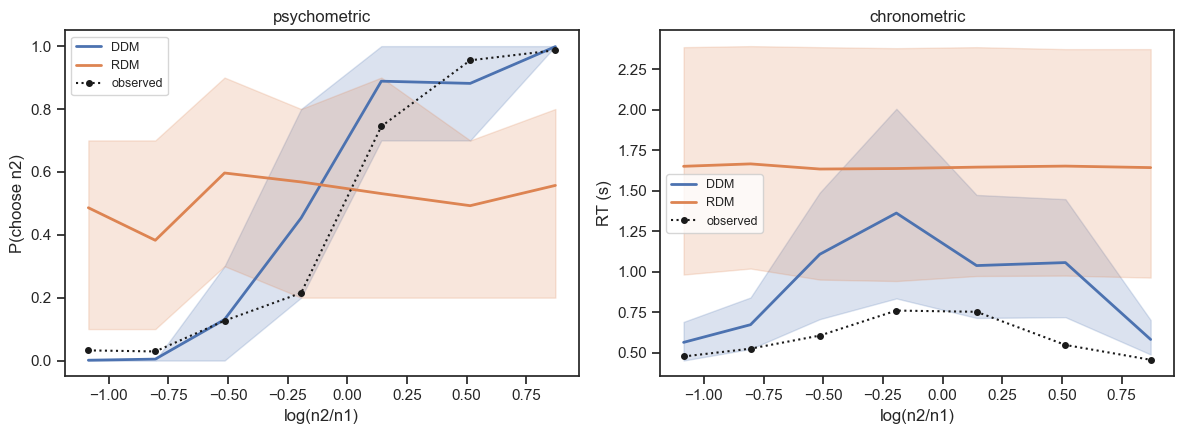

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for col, value, ax_label in [
    ('simulated_choice', 'choice', 'P(choose n2)'),
    ('simulated_rt', 'rt', 'RT (s)'),
]:
    ax = axes[0] if value == 'choice' else axes[1]
    obs = obs_group_mean(df_obs, value, ['log_ratio_bin']).sort_index()
    for label, ppc_full, color in [('DDM', ppc_ddm_full, 'C0'),
                                    ('RDM', ppc_race_full, 'C1')]:
        wide = _wide(col, ppc_full, ['log_ratio_bin'])
        s = summarize_ppc_group(wide, condition_cols=['log_ratio_bin'], hdi_prob=0.94).sort_index()
        ax.fill_between(s.index, s['hdi025'], s['hdi975'], alpha=0.2, color=color)
        ax.plot(s.index, s['p_predicted'], color=color, label=label, linewidth=2)
    ax.plot(obs.index, obs.values, 'k:', marker='o', markersize=4, label='observed')
    ax.set_xlabel('log(n2/n1)')
    ax.set_ylabel(ax_label)
    ax.set_title('psychometric' if value == 'choice' else 'chronometric')
    ax.legend(fontsize=9)
plt.tight_layout()

### Size effect

Bin trials by geometric-mean magnitude (3 bands) × |log(n2/n1)| (5 bins). The DDM with Weber noise predicts *slower* RTs at larger magnitudes (at fixed difficulty); the RDM with $v_k = \log n_k$ predicts the opposite — *faster*. The data should disambiguate.

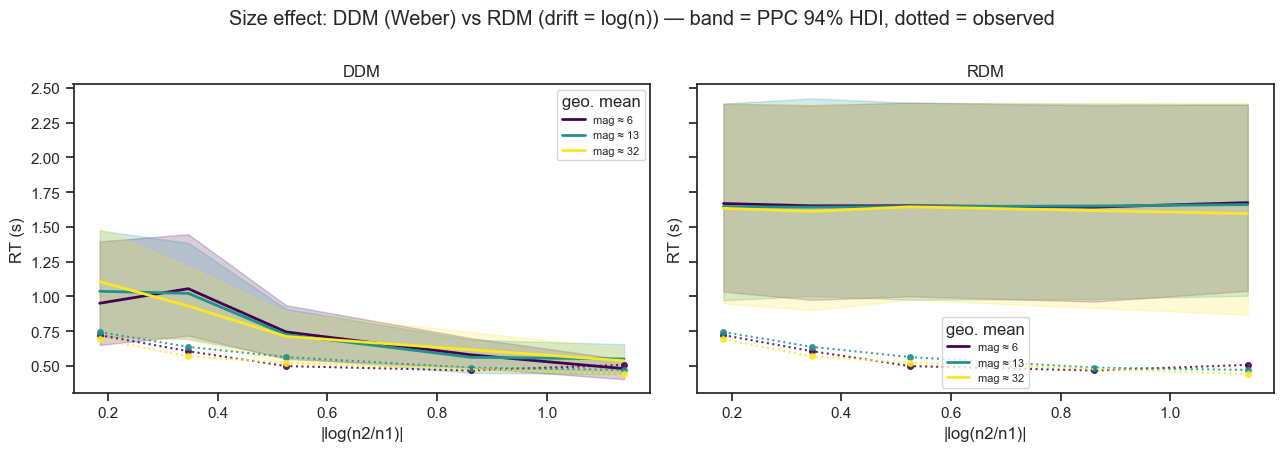

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (label, ppc_full) in zip(axes, [('DDM', ppc_ddm_full), ('RDM', ppc_race_full)]):
    wide = _wide('simulated_rt', ppc_full, ['mag_bin', 'abs_log_ratio_bin'])
    s = summarize_ppc_group(wide, condition_cols=['mag_bin', 'abs_log_ratio_bin'], hdi_prob=0.94)
    obs = obs_group_mean(df_obs, 'rt', ['mag_bin', 'abs_log_ratio_bin'])
    mag_bins = sorted(s.index.get_level_values('mag_bin').unique())
    for i, mb in enumerate(mag_bins):
        sm = s.xs(mb, level='mag_bin').sort_index()
        color = plt.cm.viridis(i / max(1, len(mag_bins) - 1))
        ax.fill_between(sm.index, sm['hdi025'], sm['hdi975'], alpha=0.2, color=color)
        ax.plot(sm.index, sm['p_predicted'], color=color, label=f'mag ≈ {mb:.0f}', linewidth=2)
        o = obs.xs(mb, level='mag_bin').sort_index()
        ax.plot(o.index, o.values, ':', color=color, marker='o', markersize=4, alpha=0.85)
    ax.set(xlabel='|log(n2/n1)|', ylabel='RT (s)', title=label)
    ax.legend(title='geo. mean', fontsize=8)
fig.suptitle('Size effect: DDM (Weber) vs RDM (drift = log(n)) — band = PPC 94% HDI, dotted = observed', y=1.00)
plt.tight_layout()

## Quantitative model comparison via PSIS-LOO

Per-trial log-likelihood is computed post-hoc (since `pm.Potential` doesn't auto-store it). The expected log point-wise predictive density (ELPD) is then estimated via Pareto-smoothed importance-sampling LOO.

In [8]:
import pymc as pm

print('Computing per-trial log-likelihood (auto via pm.compute_log_likelihood)...')
with m_ddm.estimation_model:
    pm.compute_log_likelihood(idata_ddm, extend_inferencedata=True)
with m_race.estimation_model:
    pm.compute_log_likelihood(idata_race, extend_inferencedata=True)

loo_ddm  = az.loo(idata_ddm,  var_name='ll')
loo_race = az.loo(idata_race, var_name='ll')
print('\n--- DDM LOO ---')
print(loo_ddm)
print('\n--- RDM LOO ---')
print(loo_race)

Computing per-trial log-likelihood (auto via pm.compute_log_likelihood)...


Output()

Output()


--- DDM LOO ---


Computed from 2000 posterior samples and 1234 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -273.71    46.99
p_loo       57.97        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1199   97.2%
   (0.70, 1]   (bad)        28    2.3%
   (1, Inf)   (very bad)    7    0.6%


--- RDM LOO ---
Computed from 2000 posterior samples and 1234 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -181625904474.45  11885552514.07
p_loo    181625927440.62        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      174   14.1%
   (0.70, 1]   (bad)        40    3.2%
   (1, Inf)   (very bad) 1020   82.7%



In [9]:
compare = az.compare({
    'DDM': idata_ddm,
    'RDM': idata_race,
}, ic='loo', var_name=None)
compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
DDM,0,-2.737074e+02,5.796945e+01,0.000000e+00,1.0,4.699167e+01,0.000000e+00,True,log
RDM,1,-1.816259e+11,1.816259e+11,1.816259e+11,0.0,1.188555e+10,1.188555e+10,True,log
